# CIMA 基因型预处理与 PCA

本 notebook 用于完成 CIMA 项目的基因型样本整理、样本 ID 统一、meta 对齐、LD pruning 和 PCA。

当前目标：
1. 将原始 VCF 转为 plink2 格式
2. 将基因型样本名统一改为 `BGE编号`
3. 与 meta 信息对齐，确定可用于分析的样本集合
4. 在对齐样本上进行 LD pruning
5. 计算 PCA，供后续 GWAS 协变量使用

---

## 主要中间文件说明

### 原始转换结果
- `CIMA_raw.pgen / .pvar / .psam`
  - 由原始 VCF 直接转换得到
  - 样本名仍为原始格式，如 `E-B21106356138-4_E-B21106356138-4`

### 重命名后的基因型文件
- `CIMA_BGEID.pgen / .pvar / .psam`
  - 将基因型样本名统一改为 `BGE编号`
  - 例如：`E-B21106356138`

### 与 meta 对齐后的基因型文件
- `CIMA_BGEID_metaMatched.pgen / .pvar / .psam`
  - 仅保留同时存在于 meta 和 genotype 中的样本
  - 当前交集样本数为 443

### PCA 相关文件
- `CIMA_pca_prune.prune.in`
  - LD pruning 后保留的 SNP 列表
- `CIMA_pca_prune.prune.out`
  - LD pruning 后剔除的 SNP 列表
- `CIMA_pca.eigenvec`
  - 每个样本的 PCA 坐标（PC1, PC2, ...）
- `CIMA_pca.eigenval`
  - 各主成分对应的特征值

In [8]:
# 检查基因型文件
!bcftools query -l /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/raw/CIMA/Gene/CIMA_phasing.merged.vcf.gz | head
!bcftools query -l /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/raw/CIMA/Gene/CIMA_phasing.merged.vcf.gz | wc -l
!mkdir /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/
!bcftools query -l /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/raw/CIMA/Gene/CIMA_phasing.merged.vcf.gz > /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/genotype_samples.txt

E-B21100458292-4_E-B21100458292-4
E-B21103279967-4_E-B21103279967-4
E-B21105477143-4_E-B21105477143-4
E-B21106356138-4_E-B21106356138-4
E-B21106792844-4_E-B21106792844-4
E-B21107799305-4_E-B21107799305-4
E-B21108122365-4_E-B21108122365-4
E-B21116522625-4_E-B21116522625-4
E-B21116844489-4_E-B21116844489-4
E-B21122061361-4_E-B21122061361-4
443


In [11]:
# 改名
import pandas as pd
from pathlib import Path

geno_path = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/genotype_samples.txt")
out_path = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/rename_samples.tsv")

geno = pd.read_csv(geno_path, header=None, names=["old_id"])
geno["old_id"] = geno["old_id"].astype(str).str.strip()

geno["new_id"] = (
    geno["old_id"]
    .str.split("_").str[0]      # 取前半段
    .str.replace(r"-4$", "", regex=True)   # 去掉末尾 -4
)

print(geno.head())
print("n old:", geno["old_id"].nunique())
print("n new:", geno["new_id"].nunique())

geno.to_csv(out_path, sep="\t", index=False, header=False)
print("saved:", out_path)
# 检查是否有重复
dup = geno[geno["new_id"].duplicated(keep=False)].sort_values("new_id")
print(dup)

                              old_id          new_id
0  E-B21100458292-4_E-B21100458292-4  E-B21100458292
1  E-B21103279967-4_E-B21103279967-4  E-B21103279967
2  E-B21105477143-4_E-B21105477143-4  E-B21105477143
3  E-B21106356138-4_E-B21106356138-4  E-B21106356138
4  E-B21106792844-4_E-B21106792844-4  E-B21106792844
n old: 443
n new: 443
saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/rename_samples.tsv
Empty DataFrame
Columns: [old_id, new_id]
Index: []


In [13]:
# 转成 pgen
!mkdir -p /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype

!plink2 \
  --vcf /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/raw/CIMA/Gene/CIMA_phasing.merged.vcf.gz \
  --make-pgen \
  --out /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_raw

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_raw.log.
Options in effect:
  --make-pgen
  --out /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_raw
  --vcf /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/raw/CIMA/Gene/CIMA_phasing.merged.vcf.gz

Start time: Mon Apr 13 14:03:18 2026
241108 MiB RAM detected, ~188617 available; reserving 120554 MiB for main
workspace.
Using up to 20 threads (change this with --threads).
--vcf: 13698278 variants scanned.
--vcf: 13696k variants converted.
/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_raw-temporary.pgen
+
/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_raw-temporary.pvar.zst
+
/mnt/zzbnew/peixu

In [14]:
!head -n 5 /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_raw.psam

#IID	SEX
E-B21100458292-4_E-B21100458292-4	NA
E-B21103279967-4_E-B21103279967-4	NA
E-B21105477143-4_E-B21105477143-4	NA
E-B21106356138-4_E-B21106356138-4	NA


## Step 2. 将基因型样本 ID 统一为 BGE编号

原始基因型样本名格式为：

`E-B21106356138-4_E-B21106356138-4`

而 meta 数据中使用的是 `BGE编号`，例如：

`E-B21106356138`

为了便于和 meta、表型文件统一，本步骤将基因型样本名改为 `BGE编号`。

处理规则：
- 取样本名中 `_` 前的部分
- 去掉末尾的 `-4`

例如：
- 原始：`E-B21106356138-4_E-B21106356138-4`
- 新名：`E-B21106356138`

输出文件：
- `update_ids.tsv`：plink2 用的样本重命名映射表
- `CIMA_BGEID.pgen / .pvar / .psam`

In [16]:
import pandas as pd
from pathlib import Path

psam_path = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_raw.psam")
out_path = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/update_ids.tsv")

psam = pd.read_csv(psam_path, sep=r"\s+")
print("columns:", psam.columns.tolist())
display(psam.head())

# 自动识别 IID 列
if "IID" in psam.columns:
    iid_col = "IID"
elif "#IID" in psam.columns:
    iid_col = "#IID"
else:
    raise ValueError(f"没找到 IID 列，当前列名: {psam.columns.tolist()}")

# 自动识别 FID 列；如果没有，就用 0
if "#FID" in psam.columns:
    fid = psam["#FID"].astype(str)
elif "FID" in psam.columns:
    fid = psam["FID"].astype(str)
else:
    fid = pd.Series(["0"] * len(psam), index=psam.index)

iid = psam[iid_col].astype(str).str.strip()

new_id = (
    iid
    .str.split("_").str[0]
    .str.replace(r"-4$", "", regex=True)
)

update = pd.DataFrame({
    "oldFID": fid,
    "oldIID": iid,
    "newFID": new_id,
    "newIID": new_id,
})

print(update.head())
print("old IID unique:", update["oldIID"].nunique())
print("new IID unique:", update["newIID"].nunique())

dup = update[update["newIID"].duplicated(keep=False)].sort_values("newIID")
print("duplicated newIID rows:", dup.shape[0])
if dup.shape[0] > 0:
    display(dup.head(20))

update.to_csv(out_path, sep="\t", index=False, header=False)
print("saved:", out_path)

columns: ['#IID', 'SEX']


,#IID,SEX
0,E-B21100458292-4_E-B21100458292-4,NaN
1,E-B21103279967-4_E-B21103279967-4,NaN
2,E-B21105477143-4_E-B21105477143-4,NaN
3,E-B21106356138-4_E-B21106356138-4,NaN
4,E-B21106792844-4_E-B21106792844-4,NaN


  oldFID                             oldIID          newFID          newIID
0      0  E-B21100458292-4_E-B21100458292-4  E-B21100458292  E-B21100458292
1      0  E-B21103279967-4_E-B21103279967-4  E-B21103279967  E-B21103279967
2      0  E-B21105477143-4_E-B21105477143-4  E-B21105477143  E-B21105477143
3      0  E-B21106356138-4_E-B21106356138-4  E-B21106356138  E-B21106356138
4      0  E-B21106792844-4_E-B21106792844-4  E-B21106792844  E-B21106792844
old IID unique: 443
new IID unique: 443
duplicated newIID rows: 0
saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/update_ids.tsv


In [17]:
!plink2 \
  --pfile /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_raw \
  --update-ids /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/update_ids.tsv \
  --make-pgen \
  --out /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID.log.
Options in effect:
  --make-pgen
  --out /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID
  --pfile /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_raw
  --update-ids /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/update_ids.tsv

Start time: Mon Apr 13 14:08:32 2026
241108 MiB RAM detected, ~188164 available; reserving 120554 MiB for main
workspace.
Using up to 20 threads (change this with --threads).
443 samples (0 females, 0 males, 443 ambiguous; 443 founders) loaded from
/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_raw.psam.
13698278 variants loaded from

In [18]:
!head -n 10 /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID.psam


#FID	IID	SEX
E-B21100458292	E-B21100458292	NA
E-B21103279967	E-B21103279967	NA
E-B21105477143	E-B21105477143	NA
E-B21106356138	E-B21106356138	NA
E-B21106792844	E-B21106792844	NA
E-B21107799305	E-B21107799305	NA
E-B21108122365	E-B21108122365	NA
E-B21116522625	E-B21116522625	NA
E-B21116844489	E-B21116844489	NA


In [19]:
import pandas as pd
from pathlib import Path

psam_path = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID.psam")
outdir = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/sample_intersection")
outdir.mkdir(parents=True, exist_ok=True)

psam = pd.read_csv(psam_path, sep=r"\s+")

if "#IID" in psam.columns:
    iid_col = "#IID"
elif "IID" in psam.columns:
    iid_col = "IID"
else:
    raise ValueError(f"没找到 IID 列: {psam.columns.tolist()}")

geno_ids = psam[[iid_col]].copy()
geno_ids.columns = ["BGE编号"]
geno_ids["BGE编号"] = geno_ids["BGE编号"].astype(str).str.strip()

geno_ids.to_csv(outdir / "genotype_BGEID_samples.txt", index=False, header=False)
print("genotype n:", geno_ids["BGE编号"].nunique())
print("saved:", outdir / "genotype_BGEID_samples.txt")
display(geno_ids.head())

genotype n: 443
saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/sample_intersection/genotype_BGEID_samples.txt


,BGE编号
0,E-B21100458292
1,E-B21103279967
2,E-B21105477143
3,E-B21106356138
4,E-B21106792844


## Step 3. genotype 与 meta 样本对齐

这一步的目的是确认哪些基因型样本在 meta 信息中有对应记录。

当前结果：
- meta 样本数：467
- genotype 样本数：443
- 交集样本数：443
- 仅 meta 有、genotype 没有：24
- genotype 中不存在孤立样本

结论：
- 所有基因型样本都能在 meta 中找到对应信息
- 后续 PCA 和 GWAS 可以基于这 443 个样本继续进行

输出文件：
- `meta_genotype_common_BGEID.txt`
- `meta_only_BGEID.txt`
- `geno_only_BGEID.txt`
- `CIMA_BGEID_metaMatched.pgen / .pvar / .psam`

In [20]:
import pandas as pd
from pathlib import Path

meta_path = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/meta/CIMA_meta_sheet2_clean.csv")
psam_path = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID.psam")
outdir = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/sample_intersection")
outdir.mkdir(parents=True, exist_ok=True)

meta = pd.read_csv(meta_path)
psam = pd.read_csv(psam_path, sep=r"\s+")

# genotype IID列
if "#IID" in psam.columns:
    iid_col = "#IID"
elif "IID" in psam.columns:
    iid_col = "IID"
else:
    raise ValueError(f"没找到 IID 列: {psam.columns.tolist()}")

meta["BGE编号"] = meta["BGE编号"].astype(str).str.strip()
geno_ids = psam[iid_col].astype(str).str.strip()

meta_ids = set(meta["BGE编号"])
geno_ids = set(geno_ids)

common = sorted(meta_ids & geno_ids)
meta_only = sorted(meta_ids - geno_ids)
geno_only = sorted(geno_ids - meta_ids)

print("meta unique:", len(meta_ids))
print("geno unique:", len(geno_ids))
print("common:", len(common))
print("meta only:", len(meta_only))
print("geno only:", len(geno_only))

pd.Series(common).to_csv(outdir / "meta_genotype_common_BGEID.txt", index=False, header=False)
pd.Series(meta_only).to_csv(outdir / "meta_only_BGEID.txt", index=False, header=False)
pd.Series(geno_only).to_csv(outdir / "geno_only_BGEID.txt", index=False, header=False)

print("saved:")
print(outdir / "meta_genotype_common_BGEID.txt")
print(outdir / "meta_only_BGEID.txt")
print(outdir / "geno_only_BGEID.txt")

meta unique: 467
geno unique: 443
common: 443
meta only: 24
geno only: 0
saved:
/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/sample_intersection/meta_genotype_common_BGEID.txt
/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/sample_intersection/meta_only_BGEID.txt
/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/sample_intersection/geno_only_BGEID.txt


In [21]:
import pandas as pd
from pathlib import Path

infile = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/sample_intersection/meta_genotype_common_BGEID.txt")
outfile = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/sample_intersection/meta_genotype_common_BGEID.keep")

x = pd.read_csv(infile, header=None, names=["IID"])
keep = pd.DataFrame({
    "FID": x["IID"].astype(str),
    "IID": x["IID"].astype(str),
})
keep.to_csv(outfile, sep="\t", index=False, header=False)

print(outfile)
display(keep.head())
print("n keep =", keep.shape[0])

/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/sample_intersection/meta_genotype_common_BGEID.keep


,FID,IID
0,E-B21100458292,E-B21100458292
1,E-B21103279967,E-B21103279967
2,E-B21105477143,E-B21105477143
3,E-B21106356138,E-B21106356138
4,E-B21106792844,E-B21106792844


n keep = 443


## Step 4. PCA 前的 SNP 过滤与 LD pruning

PCA 不应直接在全部 SNP 上运行，因为高 LD 区域会导致局部相关 SNP 被重复计权，从而影响主成分对整体群体结构的刻画。

因此，在 PCA 前先进行以下处理：
- 仅保留常染色体（1-22）
- 仅保留双等位 SNP
- 去除低频位点（MAF < 0.01）
- 去除缺失率高的位点（geno > 0.01）
- 去除明显偏离 HWE 的位点（HWE < 1e-4）
- 进行 LD pruning：`--indep-pairwise 200 50 0.2`

输出文件：
- `CIMA_pca_prune.prune.in`
- `CIMA_pca_prune.prune.out`

说明：
- `prune.in` 为用于 PCA 的 SNP 集合
- `prune.out` 为被剔除的 SNP

In [22]:
!plink2 \
  --pfile /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID \
  --keep /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/sample_intersection/meta_genotype_common_BGEID.keep \
  --make-pgen \
  --out /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched.log.
Options in effect:
  --keep /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/sample_intersection/meta_genotype_common_BGEID.keep
  --make-pgen
  --out /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched
  --pfile /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID

Start time: Mon Apr 13 14:12:45 2026
241108 MiB RAM detected, ~187943 available; reserving 120554 MiB for main
workspace.
Using up to 20 threads (change this with --threads).
443 samples (0 females, 0 males, 443 ambiguous; 443 founders) loaded from
/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genot

In [23]:
!plink2 \
  --pfile /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched \
  --chr 1-22 \
  --snps-only just-acgt \
  --max-alleles 2 \
  --maf 0.01 \
  --geno 0.01 \
  --hwe 1e-4 \
  --indep-pairwise 200 50 0.2 \
  --out /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca_prune

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca_prune.log.
Options in effect:
  --chr 1-22
  --geno 0.01
  --hwe 1e-4
  --indep-pairwise 200 50 0.2
  --maf 0.01
  --max-alleles 2
  --out /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca_prune
  --pfile /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched
  --snps-only just-acgt

Start time: Mon Apr 13 14:13:37 2026
241108 MiB RAM detected, ~187923 available; reserving 120554 MiB for main
workspace.
Using up to 20 threads (change this with --threads).
443 samples (0 females, 0 males, 443 ambiguous; 443 founders) loaded from
/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched.ps

## Step 5. PCA

这一步使用 LD pruning 后的 SNP 集合进行 PCA，得到样本层面的主成分坐标。

输入：
- `CIMA_BGEID_metaMatched`
- `CIMA_pca_prune.prune.in`

输出：
- `CIMA_pca.eigenvec`：样本的 PC 坐标
- `CIMA_pca.eigenval`：各 PC 的特征值

说明：
- 这里先计算前 10 个 PC，目的是保留更多信息供后续判断
- “先算 10 个 PC” 不等于 “GWAS 中一定放 20 个”
- 后续会根据 PCA 结果、显著性检验和模型表现决定最终纳入多少个 PC

In [24]:
!plink2 \
  --pfile /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched \
  --extract /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca_prune.prune.in \
  --pca 10 approx \
  --out /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca.log.
Options in effect:
  --extract /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca_prune.prune.in
  --out /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca
  --pca 10 approx
  --pfile /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched

Start time: Mon Apr 13 14:16:39 2026
241108 MiB RAM detected, ~187689 available; reserving 120554 MiB for main
workspace.
Using up to 20 threads (change this with --threads).
443 samples (0 females, 0 males, 443 ambiguous; 443 founders) loaded from
/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched.p

## Step 6. 按地域检查 PCA 结果

这一步的目的是观察样本地域信息（当前使用 `籍贯` 列）与 PCA 主成分之间的关系。

主要关注：
- 不同地域样本在 PCA 空间中是否存在分离趋势
- PC1 / PC2 / PC3 是否与地域分布相关
- 是否存在某些明显偏离的地域群体

本步骤处理内容：
1. 将 PCA 结果合并回 meta 表
2. 对 `籍贯` 进行标准化，统一到省级
3. 对异常值、缺失值进行修正
   - `如东` 归为 `江苏`
   - `漏填` 视为缺失
4. 基于省份进一步划分：
   - 大区（华北、华东、华中、华南、西南、西北、东北、港澳台）
   - 南北分组

说明：
- 当前 `籍贯` 不完全等同于样本真实祖源，只能作为粗略地域变量
- 这一步主要是探索性分析，不作为严格群体分层定义
- 后续若类别过多，会进一步将低频类别合并为“其他”

In [48]:
from pathlib import Path
import numpy as np
import pandas as pd

# =========================
# 1. 路径
# =========================
meta_path = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/meta/CIMA_meta_sheet2_clean.csv")
pca_path = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca.eigenvec")
out_path = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/meta/CIMA_meta_with_pca.csv")

qc_dir = out_path.parent / "origin_qc"
qc_dir.mkdir(parents=True, exist_ok=True)

# =========================
# 2. 读取数据
# =========================
meta = pd.read_csv(meta_path)
pca = pd.read_csv(pca_path, sep=r"\s+", header=None)

pca.columns = ["FID", "IID"] + [f"PC{i}" for i in range(1, pca.shape[1] - 1)]

print("meta shape:", meta.shape)
print("pca shape:", pca.shape)

# =========================
# 3. 确定 merge key
# =========================
candidate_meta_keys = ["CIMA_ID", "CIMA ID", "IID", "sample_id", "SampleID"]
meta_key = None
for c in candidate_meta_keys:
    if c in meta.columns:
        meta_key = c
        break

if meta_key is None:
    raise ValueError(f"meta 中没找到可用于和 PCA 合并的 ID 列，候选列: {candidate_meta_keys}")

meta[meta_key] = meta[meta_key].astype(str).str.strip()
pca["IID"] = pca["IID"].astype(str).str.strip()

print("use meta_key:", meta_key)

# =========================
# 4. 合并 PCA
# =========================
meta_pca = meta.merge(
    pca.drop(columns=["FID"]),
    left_on=meta_key,
    right_on="IID",
    how="left"
)

print("merged shape:", meta_pca.shape)
print("PCA matched:", meta_pca["PC1"].notna().sum(), "/", len(meta_pca))

# =========================
# 5. 标准化 籍贯 -> 省份
# =========================
# 只保留最小规则：
# - 如东 -> 江苏
# - 漏填/空白 -> 缺失
# - 省/市/自治区/特别行政区 做简单去后缀
# - 最终只接受省级行政区名单里的值，其余记为异常待检查

valid_provinces = {
    "北京", "天津", "上海", "重庆",
    "河北", "山西", "内蒙古",
    "辽宁", "吉林", "黑龙江",
    "江苏", "浙江", "安徽", "福建", "江西", "山东",
    "河南", "湖北", "湖南",
    "广东", "广西", "海南",
    "四川", "贵州", "云南", "西藏",
    "陕西", "甘肃", "青海", "宁夏", "新疆",
    "香港", "澳门", "台湾",
}

missing_values = {
    "", "nan", "None", "none", "NULL", "null", "NA", "N/A",
    "漏填", "未填", "未知", "不详", "无"
}

def clean_origin_to_province(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    if s in missing_values:
        return np.nan

    # 唯一已知特例
    if s == "如东":
        return "江苏"

    # 简单去常见后缀
    s = (s.replace("特别行政区", "")
           .replace("维吾尔自治区", "")
           .replace("壮族自治区", "")
           .replace("回族自治区", "")
           .replace("自治区", "")
           .replace("省", "")
           .replace("市", ""))

    if s in valid_provinces:
        return s

    return s  # 先保留，后面做 QC 检查

origin_col = "籍贯"
if origin_col not in meta_pca.columns:
    raise ValueError(f"未找到列: {origin_col}")

meta_pca["origin_raw"] = meta_pca[origin_col]
meta_pca["origin_province_std"] = meta_pca["origin_raw"].apply(clean_origin_to_province)

# 识别异常值：既不是缺失，也不在标准省份集合里
abnormal_mask = (
    meta_pca["origin_province_std"].notna() &
    ~meta_pca["origin_province_std"].isin(valid_provinces)
)

abnormal_df = (
    meta_pca.loc[abnormal_mask, [meta_key, "origin_raw", "origin_province_std"]]
    .copy()
    .sort_values(["origin_province_std", meta_key])
)

abnormal_summary = (
    abnormal_df["origin_province_std"]
    .value_counts(dropna=False)
    .rename_axis("abnormal_origin")
    .reset_index(name="n")
)

print("\n异常地域记录数:", abnormal_df.shape[0])
print("异常地域去重值数:", abnormal_summary.shape[0])

# 异常值这里先统一打成缺失，避免污染后续分组
meta_pca.loc[abnormal_mask, "origin_province_std"] = np.nan

# =========================
# 6. 省份 -> 大区
# =========================
province_to_region = {
    "北京": "华北", "天津": "华北", "河北": "华北", "山西": "华北", "内蒙古": "华北",
    "辽宁": "东北", "吉林": "东北", "黑龙江": "东北",
    "上海": "华东", "江苏": "华东", "浙江": "华东", "安徽": "华东", "福建": "华东", "江西": "华东", "山东": "华东",
    "河南": "华中", "湖北": "华中", "湖南": "华中",
    "广东": "华南", "广西": "华南", "海南": "华南",
    "重庆": "西南", "四川": "西南", "贵州": "西南", "云南": "西南", "西藏": "西南",
    "陕西": "西北", "甘肃": "西北", "青海": "西北", "宁夏": "西北", "新疆": "西北",
    "香港": "港澳台", "澳门": "港澳台", "台湾": "港澳台",
}

meta_pca["origin_region"] = meta_pca["origin_province_std"].map(province_to_region)

# =========================
# 7. 省份 -> 南北
# =========================
north_set = {
    "北京", "天津", "河北", "山西", "内蒙古",
    "辽宁", "吉林", "黑龙江",
    "山东",
    "陕西", "甘肃", "青海", "宁夏", "新疆",
    "河南"
}

south_set = {
    "上海", "江苏", "浙江", "安徽", "福建", "江西",
    "湖北", "湖南",
    "广东", "广西", "海南",
    "重庆", "四川", "贵州", "云南", "西藏",
    "香港", "澳门", "台湾"
}

def province_to_north_south(x):
    if pd.isna(x):
        return np.nan
    if x in north_set:
        return "北方"
    if x in south_set:
        return "南方"
    return np.nan

meta_pca["origin_north_south"] = meta_pca["origin_province_std"].apply(province_to_north_south)

# =========================
# 8. 低频类别合并（可选）
# =========================
min_count = 5
province_counts = meta_pca["origin_province_std"].value_counts(dropna=False)

meta_pca["origin_province_grouped"] = meta_pca["origin_province_std"]
low_freq_provinces = province_counts[province_counts < min_count].index
low_freq_provinces = [x for x in low_freq_provinces if pd.notna(x)]

meta_pca.loc[
    meta_pca["origin_province_grouped"].isin(low_freq_provinces),
    "origin_province_grouped"
] = "其他"

# =========================
# 9. 保存 QC
# =========================
abnormal_summary.to_csv(qc_dir / "abnormal_origin_summary.csv", index=False)
abnormal_df.to_csv(qc_dir / "abnormal_origin_detail.csv", index=False)

province_summary = (
    meta_pca["origin_province_std"]
    .value_counts(dropna=False)
    .rename_axis("origin_province_std")
    .reset_index(name="n")
)
province_summary.to_csv(qc_dir / "origin_province_summary.csv", index=False)

region_summary = (
    meta_pca["origin_region"]
    .value_counts(dropna=False)
    .rename_axis("origin_region")
    .reset_index(name="n")
)
region_summary.to_csv(qc_dir / "origin_region_summary.csv", index=False)

north_south_summary = (
    meta_pca["origin_north_south"]
    .value_counts(dropna=False)
    .rename_axis("origin_north_south")
    .reset_index(name="n")
)
north_south_summary.to_csv(qc_dir / "origin_north_south_summary.csv", index=False)

# =========================
# 10. 保存主表（覆盖）
# =========================
meta_pca.to_csv(out_path, index=False)

print("\nsaved main:")
print(out_path)

print("\nsaved qc:")
print(qc_dir / "abnormal_origin_summary.csv")
print(qc_dir / "abnormal_origin_detail.csv")
print(qc_dir / "origin_province_summary.csv")
print(qc_dir / "origin_region_summary.csv")
print(qc_dir / "origin_north_south_summary.csv")

print("\n省份分布前20：")
print(province_summary.head(20))

print("\n大区分布：")
print(region_summary)

print("\n南北分布：")
print(north_south_summary)

saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/meta/CIMA_plot_meta.csv
       编号  PC1  PC2  PC3  PC4  PC5  PC6  PC7  PC8  PC9 PC10  籍贯 省份分组  南北
0  CIMA01  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  广东   广东  南方
1  CIMA02  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  湖南   湖南  南方
2  CIMA03  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  山东   山东  北方
3  CIMA04  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  广东   广东  南方
4  CIMA05  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  湖北   湖北  南方


In [51]:
from pathlib import Path
import numpy as np
import pandas as pd

# =========================
# 1. 路径
# =========================
meta_path = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/meta/CIMA_meta_sheet2_clean.csv")
pca_path = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca.eigenvec")
out_path = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/meta/CIMA_plot_meta.csv")

# =========================
# 2. 读取数据
# =========================
meta = pd.read_csv(meta_path)
pca = pd.read_csv(pca_path, sep=r"\s+", header=None)

# eigenvec 可能第一行混入表头
if str(pca.iloc[0, 0]).strip() == "#FID":
    pca = pca.iloc[1:].copy()

pca.columns = ["FID", "IID"] + [f"PC{i}" for i in range(1, pca.shape[1] - 1)]

# =========================
# 3. 检查列
# =========================
need_cols = ["BGE编号", "籍贯"]
for col in need_cols:
    if col not in meta.columns:
        raise ValueError(f"meta里缺少列: {col}")

pc_cols = [f"PC{i}" for i in range(1, 11)]
for col in pc_cols:
    if col not in pca.columns:
        raise ValueError(f"pca里缺少列: {col}")

# =========================
# 4. 统一ID格式
# =========================
meta["BGE编号"] = meta["BGE编号"].astype(str).str.strip()
meta["籍贯"] = meta["籍贯"].astype(str).str.strip()

pca["IID"] = pca["IID"].astype(str).str.strip()

# =========================
# 5. 籍贯 -> 标准省份
# =========================
valid_provinces = {
    "北京", "天津", "上海", "重庆",
    "河北", "山西", "内蒙古",
    "辽宁", "吉林", "黑龙江",
    "江苏", "浙江", "安徽", "福建", "江西", "山东",
    "河南", "湖北", "湖南",
    "广东", "广西", "海南",
    "四川", "贵州", "云南", "西藏",
    "陕西", "甘肃", "青海", "宁夏", "新疆",
    "香港", "澳门", "台湾",
}

missing_values = {
    "", "nan", "None", "none", "NULL", "null", "NA", "N/A",
    "漏填", "未填", "未知", "不详", "无"
}

def clean_origin_to_province(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    if s in missing_values:
        return np.nan

    if s == "如东":
        return "江苏"

    s = (s.replace("特别行政区", "")
           .replace("维吾尔自治区", "")
           .replace("壮族自治区", "")
           .replace("回族自治区", "")
           .replace("自治区", "")
           .replace("省", "")
           .replace("市", ""))

    if s in valid_provinces:
        return s

    return np.nan

meta["province_std"] = meta["籍贯"].apply(clean_origin_to_province)

# =========================
# 6. 省份 -> 大区分组
# =========================
province_to_region = {
    "北京": "华北", "天津": "华北", "河北": "华北", "山西": "华北", "内蒙古": "华北",
    "辽宁": "东北", "吉林": "东北", "黑龙江": "东北",
    "上海": "华东", "江苏": "华东", "浙江": "华东", "安徽": "华东", "福建": "华东", "江西": "华东", "山东": "华东",
    "河南": "华中", "湖北": "华中", "湖南": "华中",
    "广东": "华南", "广西": "华南", "海南": "华南",
    "重庆": "西南", "四川": "西南", "贵州": "西南", "云南": "西南", "西藏": "西南",
    "陕西": "西北", "甘肃": "西北", "青海": "西北", "宁夏": "西北", "新疆": "西北",
    "香港": "港澳台", "澳门": "港澳台", "台湾": "港澳台",
}
meta["省份分组"] = meta["province_std"].map(province_to_region)

# =========================
# 7. 省份 -> 南北
# =========================
north_set = {
    "北京", "天津", "河北", "山西", "内蒙古",
    "辽宁", "吉林", "黑龙江",
    "山东", "河南",
    "陕西", "甘肃", "青海", "宁夏", "新疆"
}

south_set = {
    "上海", "江苏", "浙江", "安徽", "福建", "江西",
    "湖北", "湖南",
    "广东", "广西", "海南",
    "重庆", "四川", "贵州", "云南", "西藏",
    "香港", "澳门", "台湾"
}

def province_to_ns(x):
    if pd.isna(x):
        return np.nan
    if x in north_set:
        return "北方"
    if x in south_set:
        return "南方"
    return np.nan

meta["南北"] = meta["province_std"].apply(province_to_ns)

# =========================
# 8. 合并 PCA
# 没有 PCA 的不要，所以用 inner join
# =========================
pca_sub = pca[["IID"] + pc_cols].copy()

final_df = meta.merge(
    pca_sub,
    left_on="BGE编号",
    right_on="IID",
    how="inner"
)

# =========================
# 9. 只保留需要的列
# 编号用 IID
# =========================
final_df = final_df[
    ["IID"] + pc_cols + ["籍贯", "省份分组", "南北"]
].copy()

final_df = final_df.rename(columns={"IID": "编号"})

# =========================
# 10. 保存
# =========================
final_df.to_csv(out_path, index=False)

print("saved:", out_path)
print("shape:", final_df.shape)
print(final_df.head())

saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/meta/CIMA_plot_meta.csv
shape: (443, 14)
               编号          PC1         PC2         PC3         PC4  \
0  E-B21106356138     0.074113  -0.0199824  0.00676208  -0.0081569   
1  E-B21133356716    0.0458436  0.00368162   0.0145161   0.0982847   
2  E-B21138997257   -0.0614997   0.0268081  -0.0429469   0.0435883   
3  E-B21155258684    0.0680496  0.00176611  0.00929498  0.00835493   
4  E-B21296798284  -0.00773352   0.0021385   0.0538276   -0.052648   

          PC5           PC6         PC7         PC8         PC9         PC10  \
0   0.0337237     0.0435118  -0.0264787  0.00961432   0.0364038   -0.0044255   
1  -0.0280184    -0.0143142  -0.0482072   0.0339756  0.00584808  -0.00841217   
2  -0.0458063   -0.00777306   0.0245406   0.0401095   0.0216278   -0.0430948   
3  -0.0322596  -0.000992367  0.00724146  -0.0411653  -0.0257659   0.00931073   
4   0.0375522    0.00457704  -0.0387814  -0.0284572   -0

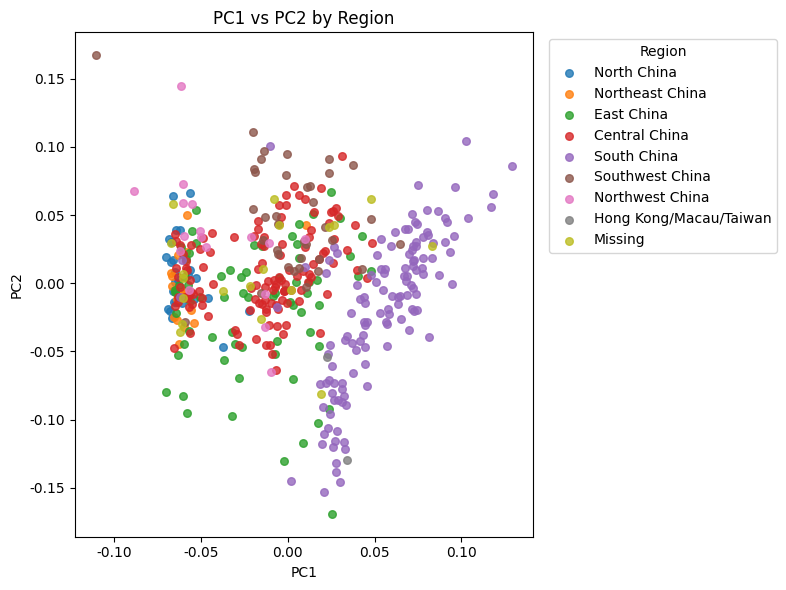

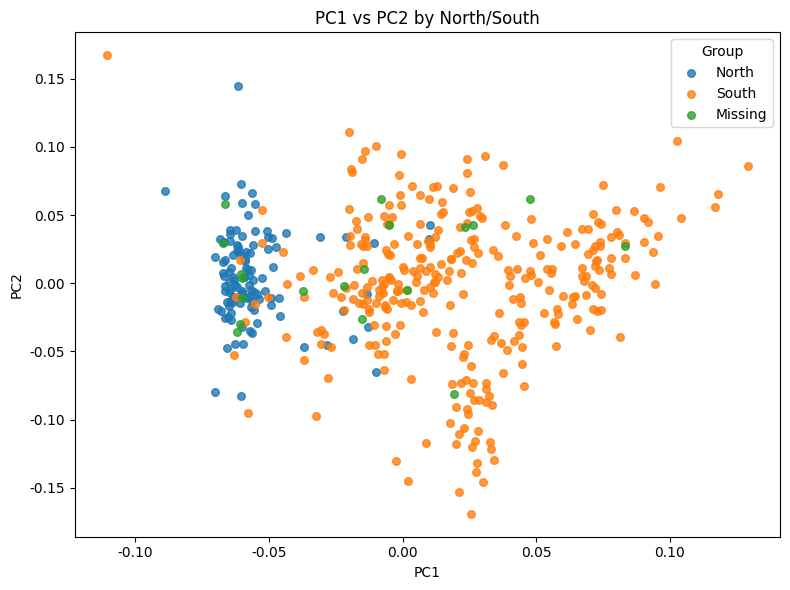

In [58]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# 读数据
plot_meta_path = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/meta/CIMA_plot_meta.csv")
df = pd.read_csv(plot_meta_path)

# 基础清洗
for col in ["PC1", "PC2"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["省份分组"] = df["省份分组"].fillna("Missing")
df["南北"] = df["南北"].fillna("Missing")
df = df.dropna(subset=["PC1", "PC2"]).copy()

# 中文分组转英文，彻底避开字体问题
region_map = {
    "华北": "North China",
    "东北": "Northeast China",
    "华东": "East China",
    "华中": "Central China",
    "华南": "South China",
    "西南": "Southwest China",
    "西北": "Northwest China",
    "港澳台": "Hong Kong/Macau/Taiwan",
    "缺失": "Missing",
    "Missing": "Missing",
}

ns_map = {
    "北方": "North",
    "南方": "South",
    "缺失": "Missing",
    "Missing": "Missing",
}

df["Region"] = df["省份分组"].map(region_map).fillna("Missing")
df["North_South"] = df["南北"].map(ns_map).fillna("Missing")

region_order = [
    "North China",
    "Northeast China",
    "East China",
    "Central China",
    "South China",
    "Southwest China",
    "Northwest China",
    "Hong Kong/Macau/Taiwan",
    "Missing",
]

ns_order = ["North", "South", "Missing"]

# 图1：PC1 vs PC2 by Region
plt.figure(figsize=(8, 6))
for group in region_order:
    sub = df[df["Region"] == group]
    if len(sub) == 0:
        continue
    plt.scatter(sub["PC1"], sub["PC2"], label=group, alpha=0.8, s=30)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 by Region")
plt.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 图2：PC1 vs PC2 by North/South
plt.figure(figsize=(8, 6))
for group in ns_order:
    sub = df[df["North_South"] == group]
    if len(sub) == 0:
        continue
    plt.scatter(sub["PC1"], sub["PC2"], label=group, alpha=0.8, s=30)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 by North/South")
plt.legend(title="Group")
plt.tight_layout()
plt.show()